# Alpha Signal Research Framework
### A cross-sectional equity signal pipeline — built for *honest* evaluation, not return maximization

This notebook is the **orchestrator**. It stitches together the six module notebooks and runs the full research pipeline end-to-end, then interprets the output the way a hedge-fund quant would.

**The core question we are answering is not 'which signal makes the most money?' but 'which signal has a *real, tradeable* edge once we strip out risk exposures and pay realistic costs?'**

We put two classic anomalies through the same rigorous wringer:

* **Momentum (12–1)** — a *slow* signal (low turnover).
* **Short-term reversion (5-day)** — a *fast* signal (high turnover).

The hypothesis under test: **momentum stays net-profitable after costs, while short-term reversion — whatever raw edge it has — is *destroyed* once turnover-based transaction costs are charged.** That contrast is the whole point. Note the word *hypothesis*: §6 reports what the data actually says, including where it disagrees with the textbook.

The universe is the **~500 S&P 500 constituents**, daily from 2018 to 2026. Breadth matters here: with ~100 names per quintile the long-short book is a portfolio rather than a handful of bets, and the Fundamental Law's $\sqrt{BR}$ argument has something real to stand on.

---
### The pipeline
```
  config  ──▶  data  ──▶  signals  ──▶  neutralize  ──▶  evaluate  ──▶  plotting
 (params)   (prices,    (raw MOM/    (1 OLS per day:   (IC, decay,   (2x2
            beta,size,   REV)         residual =        turnover,     diagnostic
            sectors)                  idiosyncratic     gross/net     report)
                                      alpha)            quintile P&L)
```
Each box is its own notebook (a faithful replacement of the original `.py` module) carrying its own methodology write-up. This notebook `%run`s them in order, so running the module notebooks' code cells here defines all the functions we need.

## 0 · Assemble the framework
`%run` executes each module notebook's **code** cells in this kernel (markdown is skipped), so every `config.*`, `load_and_clean_data`, `neutralize_signal`, … becomes available here — exactly like importing the old package. Notebooks that need parameters (`data`, `neutralize`, `evaluate`) `%run config.ipynb` internally, so config loads a few times; that is instant and harmless.

> **How to run this notebook:** open it from inside the `alpha_framework/` folder (so the relative `%run <name>.ipynb` paths and the `../output` save path resolve), then *Run All*.

In [1]:
import warnings
import numpy as np
import pandas as pd

# `%run x.ipynb` executes that notebook's CODE cells in this kernel (markdown is skipped),
# so every config value and helper function it defines lands right here in our namespace --
# the notebook equivalent of `from alpha_framework import ...`. Order follows the pipeline.
%run config.ipynb
%run data.ipynb
%run signals.ipynb
%run neutralize.ipynb
%run evaluate.ipynb
%run plotting.ipynb

pd.set_option('display.float_format', lambda x: f'{x:,.5f}')  # readable numbers in the tables
print('\nFramework assembled — all module functions are loaded.')

config loaded: 503 tickers across 11 GICS sectors | 2018-01-01 -> 2026-08-01 | mode=explicit
config loaded: 503 tickers across 11 GICS sectors | 2018-01-01 -> 2026-08-01 | mode=explicit


data helpers ready: load_and_clean_data(), compute_risk_exposures()
signal helpers ready: generate_momentum_12_1(), generate_short_term_reversion()
config loaded: 503 tickers across 11 GICS sectors | 2018-01-01 -> 2026-08-01 | mode=explicit


neutralization helpers ready: winsorize_and_standardize_cross_section(), neutralize_signal()
config loaded: 503 tickers across 11 GICS sectors | 2018-01-01 -> 2026-08-01 | mode=explicit
evaluation helpers ready: evaluate_signal_performance(), compute_quantiles_and_turnover()


plotting helper ready: generate_report_plots()

Framework assembled — all module functions are loaded.


## 1 · Data & risk exposures
Download daily adjusted prices/volumes for the static universe + SPY, build the aligned return matrix, and engineer the three risk exposures (**rolling beta**, **log dollar-volume size proxy**, **sector dummies**) that the neutralization step will regress against.

Watch for the **survivorship-bias warning** below — it is not boilerplate. Because the universe only contains names that survived to today, every performance number in this notebook is optimistic relative to what a point-in-time universe would have delivered.

In [2]:
prices, returns, volumes, spy_returns = load_and_clean_data()
exposures = compute_risk_exposures(prices, returns, volumes, spy_returns)

print(f'Price matrix   : {prices.shape[0]} days x {prices.shape[1]} stocks')
print(f'Date range     : {returns.index.min().date()} -> {returns.index.max().date()}')
print(f'Exposures      : beta {exposures["beta"].shape}, size {exposures["size"].shape}, '
      f'sector dummies {exposures["sectors"].shape[1]} cols {list(exposures["sectors"].columns)}')
display(prices.tail(3).iloc[:, :6])

/var/folders/db/84wqttfd43719yzcpsbm7nfm0000gn/T/ipykernel_436/390080133.py:13: UserWarning: 
SURVIVORSHIP-BIAS WARNING: the universe is a STATIC list of names that survived
to today. Delisted / shrunken firms are absent, so historical IC and P&L are
structurally inflated. A production book requires a point-in-time universe.

  warnings.warn(


Failed to get ticker 'ROL' reason: Failed to perform, curl: (28) Operation timed out after 10001 milliseconds with 0 bytes received. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.


Price matrix   : 2156 days x 494 stocks
Date range     : 2018-01-03 -> 2026-07-31
Exposures      : beta (2155, 494), size (2155, 494), sector dummies 10 cols ['Consumer Discretionary', 'Consumer Staples', 'Energy', 'Financials', 'Health Care', 'Industrials', 'Information Technology', 'Materials', 'Real Estate', 'Utilities']


Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL
Date,,,,,,
2026-07-29,140.30000,338.19000,263.29999,153.00999,108.00000,104.55000
2026-07-30,138.71001,333.42999,257.41000,152.08000,105.61000,101.14000
2026-07-31,138.37000,308.91000,250.94000,151.52000,105.70000,100.53000


## 2 · Raw signals
Build the two raw factor matrices `[T x N]`. Nothing is neutralized yet — these are the naive signals a first-pass researcher would test.

In [3]:
raw_signals = {
    'Momentum_12_1': generate_momentum_12_1(prices),
    'Short_Term_Reversion': generate_short_term_reversion(returns),
}
for name, mat in raw_signals.items():
    first_valid = mat.dropna(how='all').index.min()
    print(f'{name:22s}: {mat.shape[0]} days, first fully-valid cross-section ~ {first_valid.date()}')

Momentum_12_1         : 2156 days, first fully-valid cross-section ~ 2019-01-03
Short_Term_Reversion  : 2155 days, first fully-valid cross-section ~ 2018-01-09


## 3 · Neutralize, then evaluate (raw vs neutralized)
For each factor we:
1. **Neutralize** — one cross-sectional OLS per day; keep the residual (idiosyncratic alpha).
2. **Evaluate both the raw and the neutralized version** on the same leakage-safe footing (signal$_t$ vs return$_{t+1}$).

The neutralization loop is the only place we iterate over days — necessarily, since it is *one regression per day* across the ~500 stocks. Everything inside a day is vectorized. This is the slowest step (roughly 2,000 regressions per factor, each on a ~500×13 design matrix); expect it to take a minute or two.

In [4]:
def build_summary(raw_m, neut_m):
    """Pack the headline metrics into a tidy raw-vs-neutralized scorecard for one factor."""
    # Left column = metric key in the results dict, right column = the label we show.
    rows = ['mean_ic', 'ic_t_stat', 'hit_rate', 'fundamental_ir',
            'avg_turnover', 'gross_ann_return', 'annualized_net_return']
    labels = ['Mean Rank IC', 'IC t-stat', 'IC hit-rate', 'Fundamental-Law IR (IC*sqrt(BR))',
              'Daily turnover', 'Gross ann. LS return', 'NET ann. LS return (after cost)']
    return pd.DataFrame(
        {'Raw Signal': [raw_m[k] for k in rows],
         'Neutralized': [neut_m[k] for k in rows]},
        index=labels,
    )

# Run the same neutralize -> evaluate pipeline for each factor and stash the results.
RESULTS = {}
for name, raw_mat in raw_signals.items():
    print('=' * 64)
    print(f'FACTOR: {name}')
    print('=' * 64)
    print('  neutralizing (one cross-sectional OLS per day) ...')
    # neutralize_signal doesn't reload data, but silence any stray warnings so the log stays clean.
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        neut_mat = neutralize_signal(raw_mat, returns, exposures)
    # Evaluate BOTH the raw and neutralized versions on the identical leakage-safe footing.
    print('  evaluating raw and neutralized versions ...')
    raw_metrics = evaluate_signal_performance(raw_mat, returns)
    neut_metrics = evaluate_signal_performance(neut_mat, returns)
    RESULTS[name] = {'raw': raw_metrics, 'neut': neut_metrics, 'neut_matrix': neut_mat}
    print(f'\n--- {name}: raw vs neutralized scorecard ---')
    display(build_summary(raw_metrics, neut_metrics).round(5))
    print()

FACTOR: Momentum_12_1
  neutralizing (one cross-sectional OLS per day) ...


  evaluating raw and neutralized versions ...



--- Momentum_12_1: raw vs neutralized scorecard ---


,Raw Signal,Neutralized
Mean Rank IC,0.01861,0.01427
IC t-stat,3.20739,3.88489
IC hit-rate,0.55439,0.56122
Fundamental-Law IR (IC*sqrt(BR)),0.20384,0.15633
Daily turnover,0.09069,0.10021
Gross ann. LS return,0.05146,0.04506
NET ann. LS return (after cost),0.04003,0.03244



FACTOR: Short_Term_Reversion
  neutralizing (one cross-sectional OLS per day) ...


  evaluating raw and neutralized versions ...



--- Short_Term_Reversion: raw vs neutralized scorecard ---


,Raw Signal,Neutralized
Mean Rank IC,0.01227,0.00616
IC t-stat,2.79030,2.33498
IC hit-rate,0.50884,0.51639
Fundamental-Law IR (IC*sqrt(BR)),0.13444,0.06744
Daily turnover,0.68550,0.67295
Gross ann. LS return,0.12203,0.06286
NET ann. LS return (after cost),0.03566,-0.02193


### How to read the scorecard
* **Mean Rank IC** — average daily rank correlation with next-day returns. Anything consistently in the 0.02–0.05 range is a respectable single-name equity signal; the sign must match the hypothesis.
* **IC t-stat** — is the IC reliably different from zero? `|t| > ~2` is the usual bar for 'this edge is real, not noise.'
* **IC hit-rate** — fraction of days the signal points the right way. >0.5 is good; the further above, the steadier.
* **Fundamental-Law IR** — $IC\times\sqrt{BR}$: what the skill-per-bet implies for the information ratio given ~120 independent bets/year.
* **Daily turnover** — the tell. A slow signal (momentum) sits near a few % per day; a fast one (reversion) churns a large fraction of the book daily.
* **Gross vs NET annualized LS return** — the moment of truth. Gross is the paper edge; **net** is what survives after paying `turnover × 5 bps` every day. The gap between them scales directly with turnover.

## 4 · IC decay across horizons
How quickly does each signal's edge fade as we look further into the future (cumulative forward returns at t+1, +2, +3, +5, +10)? A signal whose IC peaks at t+1 and fades fast *must* be traded frequently to be harvested — which is precisely what makes it expensive.

In [5]:
# Collect the per-horizon IC dicts (raw + neutralized, both factors) into one table.
decay_tbl = {}
for name, res in RESULTS.items():
    decay_tbl[f'{name} (raw)'] = res['raw']['ic_decay']
    decay_tbl[f'{name} (neut)'] = res['neut']['ic_decay']
decay_df = pd.DataFrame(decay_tbl).T                       # rows = signals, cols = horizons
decay_df.columns = [c.replace('Horizon_', 't+') for c in decay_df.columns]  # 'Horizon_5' -> 't+5'
print('Mean Spearman rank IC vs cumulative forward return at each horizon:')
display(decay_df.round(5))

Mean Spearman rank IC vs cumulative forward return at each horizon:


,t+1,t+2,t+3,t+5,t+10
Momentum_12_1 (raw),0.01861,0.01973,0.01910,0.01581,0.01258
Momentum_12_1 (neut),0.01427,0.01456,0.01455,0.01289,0.01186
Short_Term_Reversion (raw),0.01227,0.01442,0.01532,0.01631,0.01304
Short_Term_Reversion (neut),0.00616,0.00623,0.00716,0.00765,0.00592


## 5 · Transaction-cost sensitivity
The headline 5 bps is an **assumption, not a measurement**, so the honest move is to show how much the verdict depends on it. Below we re-price the *same* book at 1, 5, 10 and 20 bps per unit of one-way turnover, and report each signal's **breakeven cost** — the level at which its gross edge is exactly consumed.

Read it this way: a signal whose breakeven sits far above realistic costs has a margin of safety; one that only works at implausibly low costs is not tradeable, however good its IC looks. Because cost scales with turnover, the fast signal's line falls away much faster than the slow one's.

In [6]:
# Net annualized return of each book, re-priced across a range of cost assumptions.
rows = []
for name, res in RESULTS.items():
    for variant in ('raw', 'neut'):
        m = res[variant]
        row = {'Factor': f'{name} ({variant})', 'Turnover/day': m['avg_turnover'],
               'Gross': m['gross_ann_return']}
        # net_by_bps is keyed by the cost level, so each becomes its own column.
        for bps, net in m['net_by_bps'].items():
            row[f'{bps:g}bp'] = net
        row['Breakeven bp'] = m['breakeven_bps']
        rows.append(row)

sens = pd.DataFrame(rows).set_index('Factor')
print('Annualized net long-short return at each assumed cost level:')
display(sens.round(4))

# State the punchline in words so the table cannot be misread.
for name, res in RESULTS.items():
    be = res['neut']['breakeven_bps']
    verdict = (f'breaks even at {be:.1f}bp — clears the 5bp assumption'
               if be > config.TRANSACTION_COST_BPS else
               f'breaks even at {be:.1f}bp — below the 5bp assumption, so it never pays')
    print(f'  {name} (neutralized): {verdict}.')

Annualized net long-short return at each assumed cost level:


,Turnover/day,Gross,1bp,5bp,10bp,20bp,Breakeven bp
Factor,,,,,,,
Momentum_12_1 (raw),0.09070,0.05150,0.04920,0.04000,0.02860,0.00580,22.51650
Momentum_12_1 (neut),0.10020,0.04510,0.04250,0.03240,0.01980,-0.00540,17.84480
Short_Term_Reversion (raw),0.68550,0.12200,0.10480,0.03570,-0.05070,-0.22350,7.06410
Short_Term_Reversion (neut),0.67300,0.06290,0.04590,-0.02190,-0.10670,-0.27630,3.70660


  Momentum_12_1 (neutralized): breaks even at 17.8bp — clears the 5bp assumption.
  Short_Term_Reversion (neutralized): breaks even at 3.7bp — below the 5bp assumption, so it never pays.


## 6 · Diagnostic plots
Render (and save to `../output/`) the 2×2 diagnostic report per factor: cumulative IC, IC decay, gross-vs-net long-short equity, and per-quintile returns.

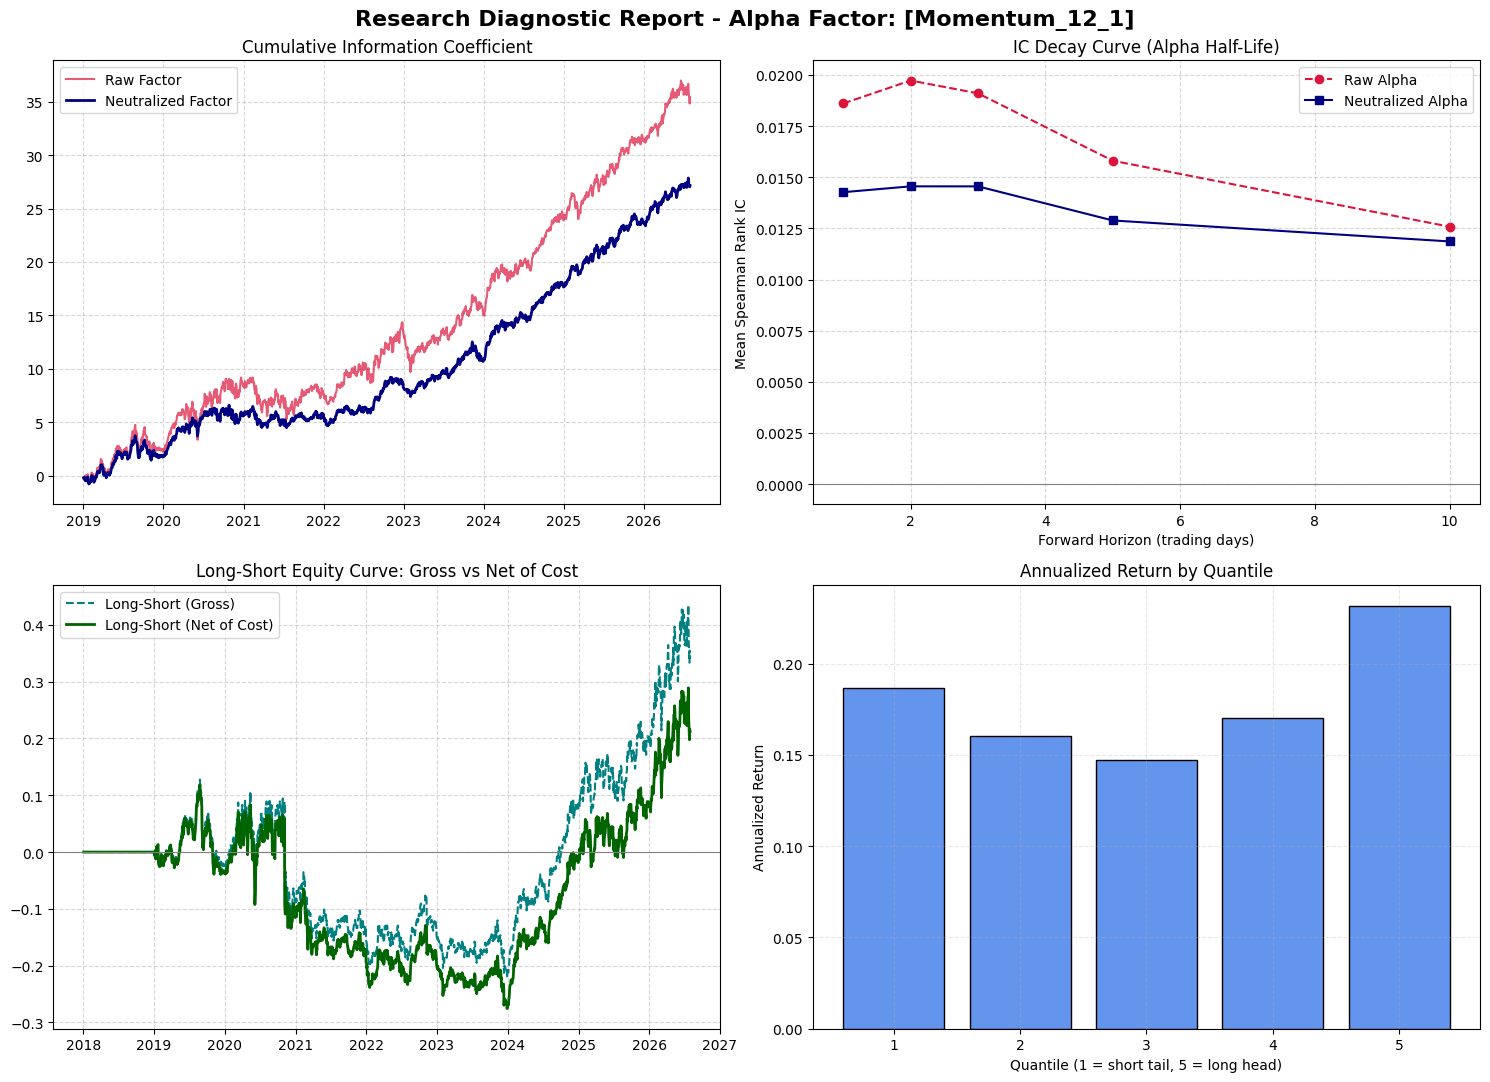

[saved] ../output/alpha_diagnostic_momentum_12_1.png


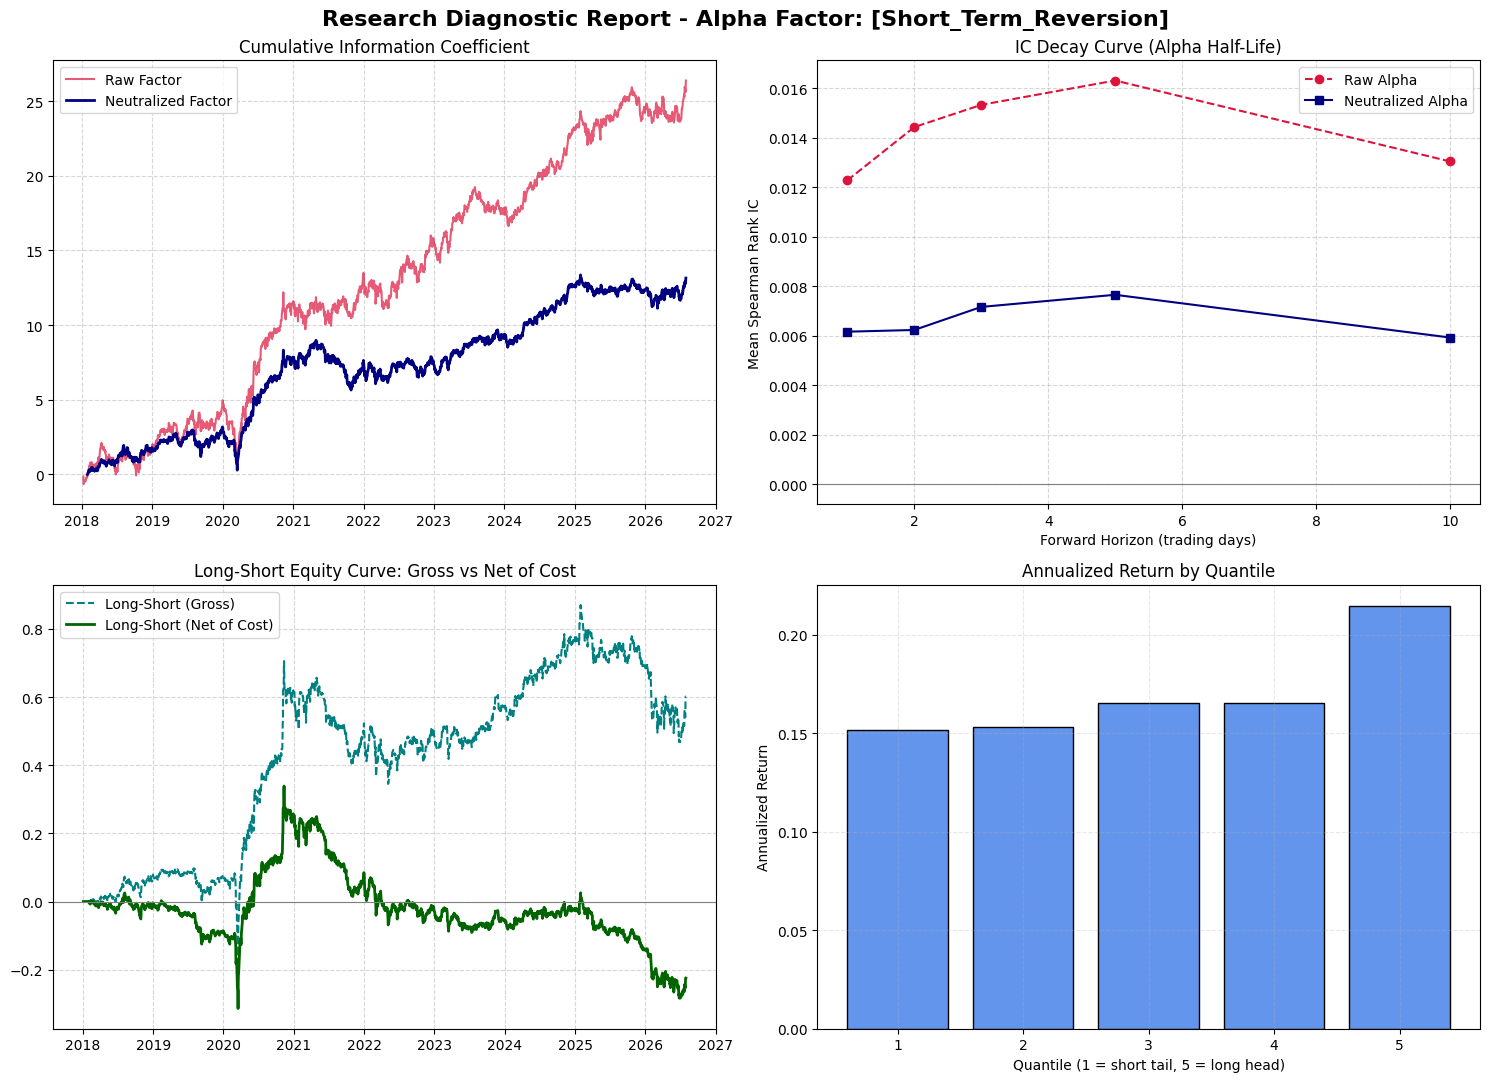

[saved] ../output/alpha_diagnostic_short_term_reversion.png

Saved diagnostic reports:
   ../output/alpha_diagnostic_momentum_12_1.png
   ../output/alpha_diagnostic_short_term_reversion.png


In [7]:
saved = []
for name, res in RESULTS.items():
    path = generate_report_plots(res['raw'], res['neut'], name, output_dir=config.OUTPUT_DIR)
    saved.append(path)
print('\nSaved diagnostic reports:')
for p in saved:
    print('  ', p)

<!--INTERPRETATION-->
## 7 · Interpretation — what the numbers say

*Written against the actual figures from this run (494 stocks that downloaded cleanly out of 503, 2018-01-03 to 2026-07-31). The verdict cell below recomputes the headline conclusion straight from `RESULTS`, so it can never drift from the tables above.*

### The headline: costs invert the ranking
This is the result the framework was built to expose, and here it is in one line:

| | Gross ann. | **Net ann. (5bp)** | Turnover/day | Breakeven |
|---|---|---|---|---|
| Momentum 12–1 (neut) | +4.51% | **+3.24%** | 10.0% | **17.8 bp** |
| Reversion 5-day (neut) | **+6.29%** | **−2.19%** | 67.3% | **3.7 bp** |

**On gross, reversion wins** (+6.29% vs +4.51%) — and on the raw signals the gap is wider still (+12.20% vs +5.15%). **On net, the ordering flips**: momentum earns +3.24% while reversion loses 2.19%. A researcher ranking these on gross P&L would pick the wrong signal. That is the entire thesis of the project, and it is not a rhetorical flourish here — it is the arithmetic.

The breakeven column says the same thing more sharply. Momentum's edge is only exhausted at **17.8 bp** per unit of one-way turnover; reversion's at **3.7 bp**. Since 5 bp is a reasonable-to-optimistic assumption for large-cap US equities, momentum has a genuine margin of safety and reversion has none — it needs frictions *below* what a real desk pays.

### Momentum (12–1) — and neutralization *helped*
- **Strongly significant.** Raw rank IC **0.0186** at **t = 3.21**; neutralized **0.0143** at **t = 3.88**, with a 56.1% hit-rate.
- **The t-stat went *up* after neutralizing** (3.21 → 3.88) even though the IC went down. That is not a paradox and it is worth being able to explain: stripping out beta, size and sector removed a chunk of *variance* (days when the factor was really just a sector bet) faster than it removed *signal*. The residual edge is smaller but far steadier — which is exactly what you want, since the t-stat, not the raw IC, is what tells you the edge is real.
- **Decay is slow and flat** (0.0143 → 0.0119 out to t+10), the signature of a signal you can hold. Low turnover follows directly from that, and so does the small 1.26%/yr cost drag.

### Short-term reversion (5-day) — a real signal that is not tradeable
- **The raw edge is real this time.** Rank IC **0.0123** at **t = 2.79** — comfortably significant, and a reversal from what a 30-name universe showed. Breadth mattered: with ~500 names the daily IC is measured far more precisely, and a genuine effect that was buried in noise became visible. Worth saying plainly: *the earlier "no edge" conclusion was a small-sample artefact, not a property of the signal.*
- **Neutralization costs it more than half its IC** (0.0123 → 0.0062, t = 2.33). Much of raw reversion was a bet on beta/sector snap-back rather than stock-specific mispricing.
- **Turnover destroys it.** At **67.3%/day** the book is almost entirely rebuilt every session, producing an **8.48%/yr** cost drag against a 6.29% gross edge. Net: **−2.19%/yr**, and it degrades fast — **−10.67%** at 10 bp.

### The obvious next step (which the decay table hands us)
Reversion's IC does not peak at t+1; it **rises through t+5** (0.0062 → 0.0077 neutralized, 0.0123 → 0.0163 raw). The reversal takes several days to play out, so re-sorting *daily* pays full freight for a signal that has not finished working. Holding a 3–5 day book would capture more of the move at a fraction of the turnover, which is the natural way to attack the 8.5%/yr drag. That is where I would take this next — not to a different signal, but to a slower rebalance of this one.

> **Honest caveats.** These are still *current* S&P 500 members held fixed back to 2018, so survivorship bias is reduced in breadth but not removed. The cost model is flat 5 bp per unit of one-way turnover with no market-impact term — and impact hurts the fast signal more, so reversion's true net is likely **worse** than shown. See §9.

> **Reproducibility.** Figures come live from `yfinance`, whose adjusted history is revised over time; re-running weeks later moves the last decimal. The qualitative verdict is stable, the exact decimals are not.

In [8]:
# Data-driven verdict — computed straight from RESULTS so it always matches this run.
rows = []
for name, res in RESULTS.items():
    n = res['neut']
    rows.append({
        'Factor': name,
        'Neut mean IC': n['mean_ic'],
        'IC t-stat': n['ic_t_stat'],
        'Turnover/day': n['avg_turnover'],
        'Gross ann.ret': n['gross_ann_return'],
        'Net ann.ret': n['annualized_net_return'],
        'Survives costs?': 'YES' if n['annualized_net_return'] > 0 else 'NO',
    })
verdict = pd.DataFrame(rows).set_index('Factor')
print('NEUTRALIZED long-short book — gross vs net verdict:')
display(verdict.round(4))

for name, res in RESULTS.items():
    n = res['neut']
    haircut = n['gross_ann_return'] - n['annualized_net_return']
    tag = 'SURVIVES costs' if n['annualized_net_return'] > 0 else 'DESTROYED by costs'
    print(f'\n{name}: gross {n["gross_ann_return"]:+.2%}/yr  ->  net {n["annualized_net_return"]:+.2%}/yr '
          f'(cost drag {haircut:.2%}/yr, turnover {n["avg_turnover"]:.1%}/day)  ==>  {tag}.')

NEUTRALIZED long-short book — gross vs net verdict:


,Neut mean IC,IC t-stat,Turnover/day,Gross ann.ret,Net ann.ret,Survives costs?
Factor,,,,,,
Momentum_12_1,0.01430,3.88490,0.10020,0.04510,0.03240,YES
Short_Term_Reversion,0.00620,2.33500,0.67300,0.06290,-0.02190,NO



Momentum_12_1: gross +4.51%/yr  ->  net +3.24%/yr (cost drag 1.26%/yr, turnover 10.0%/day)  ==>  SURVIVES costs.

Short_Term_Reversion: gross +6.29%/yr  ->  net -2.19%/yr (cost drag 8.48%/yr, turnover 67.3%/day)  ==>  DESTROYED by costs.


## 8 · The Fundamental Law of Active Management
$$ IR \approx IC \times \sqrt{BR} $$
The information ratio you can expect is your **skill per bet (IC)** multiplied by the **square root** of your **breadth (BR** = number of independent bets per period**)**. Two consequences this framework is built to respect:

1. A tiny IC is still valuable *if* you can place many independent bets — hence a cross-sectional book of hundreds of names rather than a few macro calls.
2. The **√** matters: doubling breadth only multiplies IR by ≈1.41, not 2. You cannot diversify your way out of a signal whose *net* IC is negative — which is exactly what costs do to short-term reversion.

We report `IR = IC × √BR` with an assumed breadth of 120 independent bets/year as a sanity-check on scale, **not** as a tradeable Sharpe — the honest number is the cost-aware net long-short result above.

## 9 · Known limitations & biases
This is a research skeleton, and reading it as anything more would be dishonest. The material caveats:

* **Survivorship bias (largest).** The universe is the S&P 500's *current* membership held fixed back to 2018. Companies that were dropped from the index — the weak ones — never appear, so IC and P&L are structurally inflated. Widening from 30 to ~500 names improved *breadth*, it did **not** fix this: a production system needs a **point-in-time** universe with proper index add/drop history. This remains the single largest caveat.
* **Look-ahead in the membership list itself.** Using today's index members over a 2018–2026 sample means the universe encodes information (who would still be in the index in 2026) that was not available in 2018.
* **Size proxy, not true market cap.** We use $\log(\text{price}\times\text{volume})$ because we lack point-in-time shares outstanding. It correlates with size but is not size.
* **Simplified costs.** A flat 5 bps per unit of one-way turnover ignores the spread/impact term that grows with trade size, and ignores that impact is *worse* for the fast signal — so reversion's true net P&L is likely **even worse** than shown. No slippage model, no market-impact curve. §5 sweeps the cost assumption from 1 to 20 bps so the verdict's sensitivity to it is explicit rather than hidden.
* **No borrow / short constraints.** The long-short book assumes every short is freely available and free to hold. In reality hard-to-borrow names (often the very ones a reversion signal wants to short) carry borrow fees or are un-shortable.
* **Warm-up backfill & static sectors.** Rolling beta is back-filled over its initial 60-day window (mild look-ahead), and sector labels are fixed as of today rather than point-in-time.
* **Single assumed breadth.** BR = 120 is a hand-set constant, not an estimate of the signals' true cross-sectional independence.

None of these are fatal for a *methodology* demonstration — but every one of them pushes reported performance in the optimistic direction, which is exactly why the framework leans on the most conservative number (net-of-cost long-short) for its verdict.